기업 수 - 경제활동인구 - 취업자 수 - 청년고용률 - 각종 기업 현황 - cf) 전통시장 현황

## 천안시 기업 수 변화 현황

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
comsum = pd.read_csv('기업수.csv',encoding='cp949') #천안시 2019-2020 기업수 데이터 불러오기

In [ ]:
comsum = comsum.set_index('연도')
comsum

,합계,소상공인,소기업,중기업,중소기업,대기업
연도,,,,,,
2019,277155,260385,13204,3239,276828,327
2020,294870,278066,13040,3408,294514,356


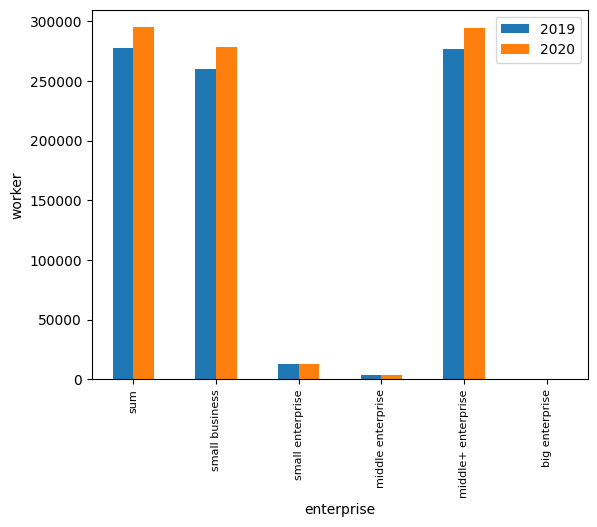

In [ ]:
comsum.T.plot(kind='bar').set_xticklabels(['sum','small business','small enterprise','middle enterprise','middle+ enterprise','big enterprise'],fontsize=8)
plt.xlabel('enterprise')
plt.ylabel('worker')
plt.legend(('2019','2020'))
plt.show()

##2024, 2025 기업수 예측

2024년 예측된 '합계' 기업 수: 365730
2025년 예측된 '합계' 기업 수: 383445
회귀선 p값: 0.000000


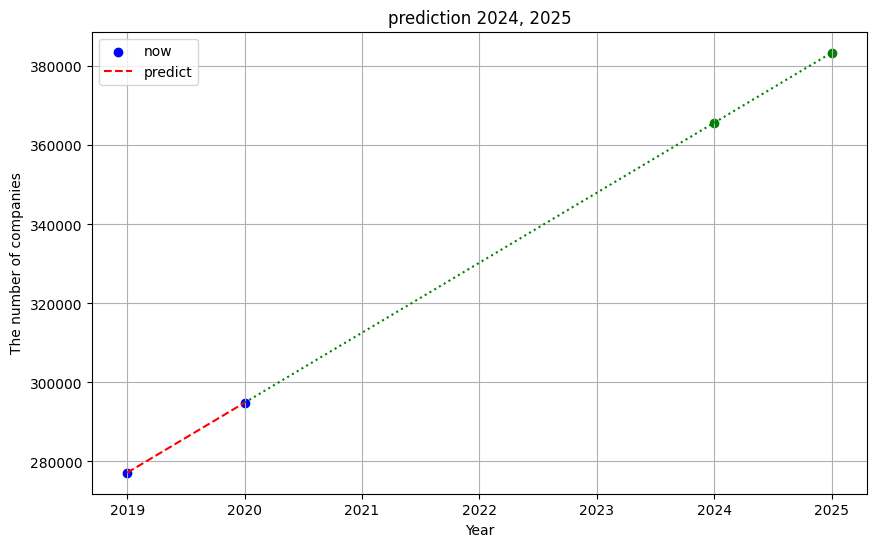

In [ ]:

from scipy.stats import linregress

# X와 y 데이터 생성
X = comsum.index.values
y = comsum['합계'].values

# 회귀 분석
slope, intercept, r_value, p_value, std_err = linregress(X, y)

# 예측할 년도 데이터 생성
future_years = np.array([2024, 2025])

# 예측값 계산
predicted_values = slope * future_years + intercept

# 결과 출력
for year, predicted_value in zip([2024, 2025], predicted_values):
    print(f"{year}년 예측된 '합계' 기업 수: {predicted_value:.0f}")

print(f"회귀선 p값: {p_value:.6f}")  # 회귀선의 p값 출력

# 그래프 그리기
plt.figure(figsize=(10, 6))
plt.scatter(comsum.index, comsum['합계'], color='blue', label='실제 데이터')
plt.plot(X, slope * X + intercept, color='red', linestyle='--', label='회귀선')
plt.scatter(future_years, predicted_values, color='green', label='예측 데이터')
plt.plot([comsum.index[-1], future_years[0]], [comsum['합계'].iloc[-1], predicted_values[0]], color='green', linestyle=':')
plt.plot([future_years[0], future_years[1]], [predicted_values[0], predicted_values[1]], color='green', linestyle=':')
plt.xlabel('Year')
plt.ylabel('The number of companies')
plt.title('prediction 2024, 2025')
plt.legend(('now','predict'))
plt.grid(True)
plt.show()


데이터가 작아 p값이 0으로 나오는 것 같다. 조금 더 많은 데이터가 있으면 원활한 회귀식을 세울 수 있을 것으로 예상된다. 데이터가 적어 arima를 사용하기도 어렵다.



In [ ]:
woman = pd.read_csv('여성경영인.csv',encoding='949') #천안시 여성경영인 기업수 데이터 불러오기

In [ ]:
woman

,연도,전체,소상공인,소기업,중기업,중소기업,대기업
0,2015,178542,86128,2805,338,89271,0
1,2016,93196,89962,2872,359,93193,3
2,2017,196604,94928,2966,408,98302,0
3,2018,105086,101490,3174,419,105083,3
4,2019,109344,105729,3180,432,109341,3
5,2020,117061,113466,3134,454,117054,7


In [ ]:
woman = woman.set_index('연도')
woman

,전체,소상공인,소기업,중기업,중소기업,대기업
연도,,,,,,
2015,178542,86128,2805,338,89271,0
2016,93196,89962,2872,359,93193,3
2017,196604,94928,2966,408,98302,0
2018,105086,101490,3174,419,105083,3
2019,109344,105729,3180,432,109341,3
2020,117061,113466,3134,454,117054,7


<Figure size 1200x2000 with 0 Axes>

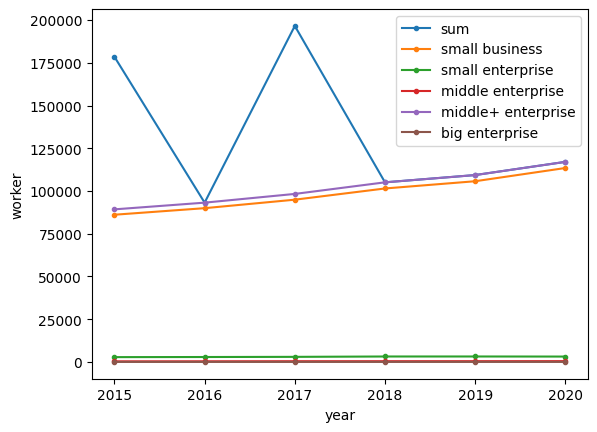

In [ ]:
plt.figure(figsize=(12, 20))
woman.plot(marker='.')
plt.xlabel('year')
plt.ylabel('worker')
plt.legend(('sum','small business','small enterprise','middle enterprise','middle+ enterprise','big enterprise'))
plt.show()

<Figure size 1200x1400 with 0 Axes>

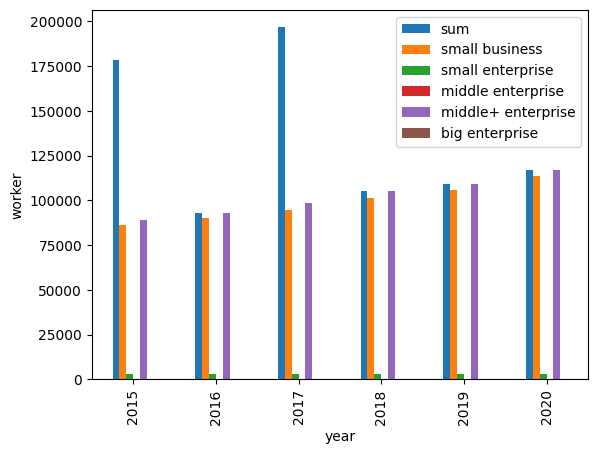

In [ ]:
plt.figure(figsize=(12, 14))
woman.plot(kind='bar')
plt.xlabel('year')
plt.ylabel('worker')
plt.legend(('sum','small business','small enterprise','middle enterprise','middle+ enterprise','big enterprise'))
plt.show()

## 2024,2025 여성 경영인 기업 수 예측

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integ

2024년 예측된 여성경영인 기업 수: 140828
2025년 예측된 여성경영인 기업 수: 123359


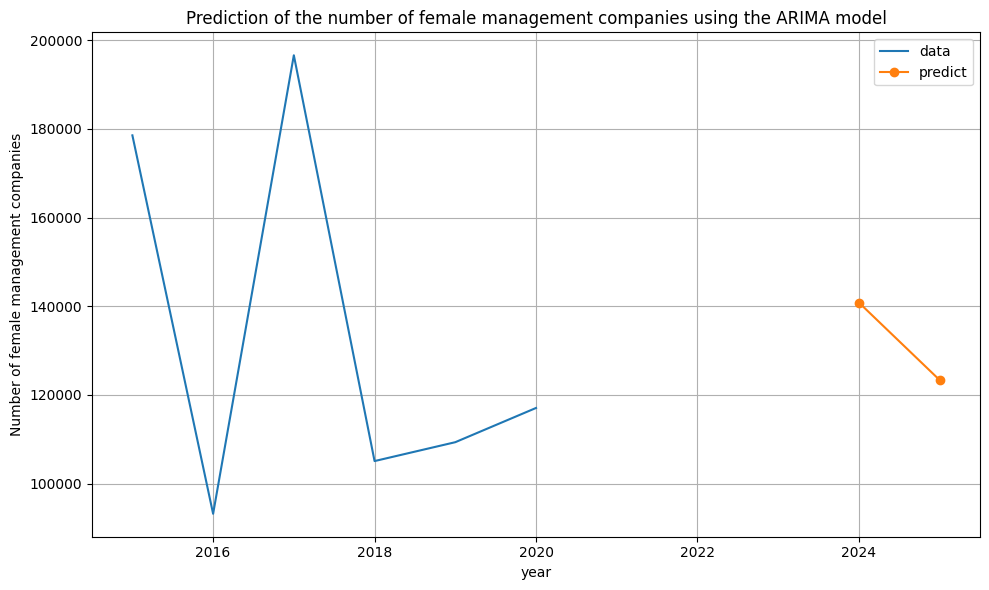

AIC: 339641.67
BIC: 339640.50


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
# ARIMA 모델 생성 및 훈련
model = ARIMA(woman['전체'], order=(1, 1, 1))  # (p, d, q) 값 설정
model_fit = model.fit()

# 2024년, 2025년 예측
future_years = [2024, 2025]
forecast = model_fit.forecast(steps=len(future_years))

# 예측 결과 출력
for year, value in zip(future_years, forecast):
    print(f"{year}년 예측된 여성경영인 기업 수: {value:.0f}")

# 예측 결과 시각화
plt.figure(figsize=(10, 6))
plt.plot(woman.index, woman['전체'], label='실제 데이터')
plt.plot(future_years, forecast, label='예측 데이터', marker='o')
plt.xlabel('year')
plt.ylabel('Number of female management companies')
plt.title('Prediction of the number of female management companies using the ARIMA model')
plt.legend(('data','predict'))
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"AIC: {model_fit.aic:.2f}")
print(f"BIC: {model_fit.bic:.2f}")

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integ

2024년 예측된 여성경영인 기업 수 (회귀): 68217
2024년 예측된 여성경영인 기업 수 (ARIMA): 140828
2025년 예측된 여성경영인 기업 수 (회귀): 58203
2025년 예측된 여성경영인 기업 수 (ARIMA): 123359
회귀선 p값: 0.389300
ARIMA 모델 AIC: 339641.67
ARIMA 모델 BIC: 339640.50


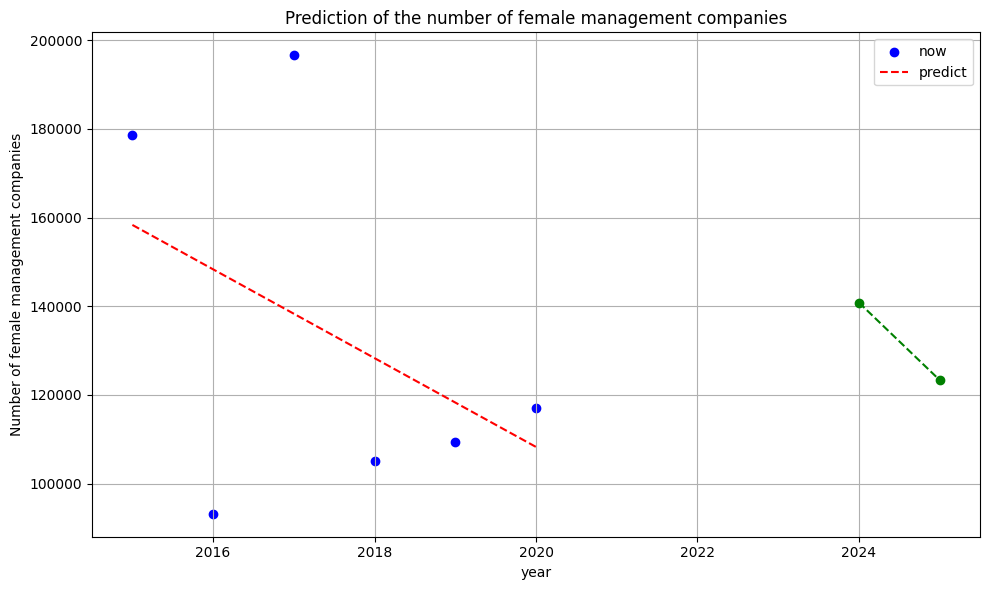

In [ ]:
from scipy.stats import linregress
from statsmodels.tsa.arima.model import ARIMA


# X와 y 데이터 생성
X = woman.index.values
y = woman['전체'].values

# 회귀 분석
slope, intercept, r_value, p_value, std_err = linregress(X, y)

# ARIMA 모델 생성 및 훈련
model = ARIMA(woman['전체'], order=(1, 1, 1))  # (p, d, q) 값 설정
model_fit = model.fit()

# AIC, BIC 값
aic = model_fit.aic
bic = model_fit.bic

# 예측할 년도 데이터 생성 (2024, 2025년)
future_years = np.array([2024, 2025])

# 회귀 모델 예측값 계산
predicted_values_reg = slope * future_years + intercept

# ARIMA 모델 예측
forecast = model_fit.forecast(steps=len(future_years))

# 결과 출력
for year, predicted_value_reg, predicted_value_arima in zip([2024, 2025], predicted_values_reg, forecast):
    print(f"{year}년 예측된 여성경영인 기업 수 (회귀): {predicted_value_reg:.0f}")
    print(f"{year}년 예측된 여성경영인 기업 수 (ARIMA): {predicted_value_arima:.0f}")

print(f"회귀선 p값: {p_value:.6f}")  # 회귀선의 p값 출력
print(f"ARIMA 모델 AIC: {aic:.2f}")
print(f"ARIMA 모델 BIC: {bic:.2f}")

# 그래프 그리기
plt.figure(figsize=(10, 6))
plt.scatter(woman.index, woman['전체'], color='blue', label='실제 데이터')
plt.plot(X, slope * X + intercept, color='red', linestyle='--', label='회귀선')
plt.plot(future_years, forecast, color='green', linestyle='--', marker='o', label='ARIMA 예측')
plt.xlabel('year')
plt.ylabel('Number of female management companies')
plt.title('Prediction of the number of female management companies')
plt.legend(('now','predict'))
plt.grid(True)
plt.tight_layout()
plt.show()


p값은 0.38로 0.05보다 높기에 유의미하다고 보기 어렵고, aic와 bic도 낮을수록 유의미하다고 할 수 있는데 현재 값은 매우 높아 예측이 어렵다.

##천안시 경제활동인구 변화 현황

In [ ]:
economy = pd.read_csv('경제활동인구.csv',encoding='cp949') #천안시 경제활동인구 데이터 불러오기

In [ ]:
economy = economy.set_index('연도')
economy

,계,남자,여자
연도,,,
2013.1/2,300.7,185.9,114.8
2013.2/2,304.6,190.7,113.9
2014.1/2,313.3,195.2,118.1
2014.2/2,316.2,193.0,123.2
2015.1/2,322.9,197.8,125.1
2015.2/2,319.9,199.1,120.8
2016.1/2,326.5,201.1,125.4
2016.2/2,330.0,207.1,122.9
2017.1/2,344.7,212.4,132.3


<Figure size 1200x1200 with 0 Axes>

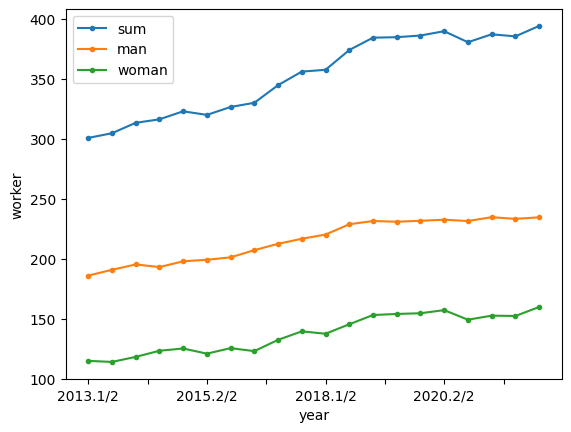

In [ ]:
plt.figure(figsize=(12, 12))
economy.plot(marker='.')
plt.xlabel('year')
plt.ylabel('worker')
plt.legend(('sum','man','woman'))
plt.show() #주황 : 남자 / 초록 : 여자

## 2024,2025 경제활동인구수 변화

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


2023.1/2년 예측된 '계' 기업 수: 397.7
2024.1/2년 예측된 '계' 기업 수: 401.3
2025.1/2년 예측된 '계' 기업 수: 404.9


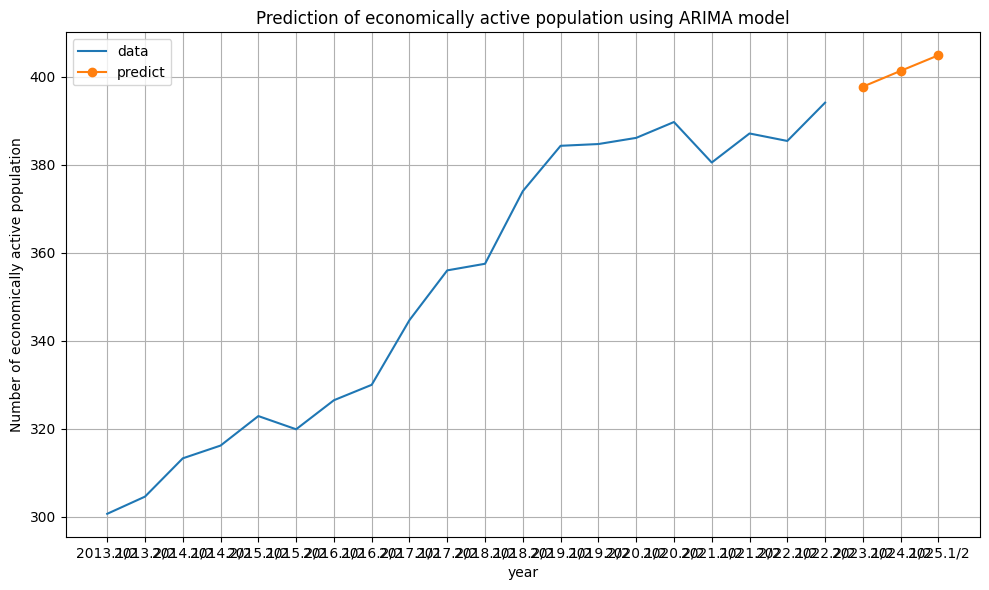

AIC: 131.82
BIC: 134.65


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
# ARIMA 모델 생성 및 훈련
model = ARIMA(economy['계'], order=(1, 1, 1))  # (p, d, q) 값 설정
model_fit = model.fit()

# 2023년, 2024년, 2025년 예측
future_years = ['2023.1/2', '2024.1/2', '2025.1/2']
forecast = model_fit.forecast(steps=len(future_years))

# 예측 결과 출력
for year, value in zip(future_years, forecast):
    print(f"{year}년 예측된 '계' 기업 수: {value:.1f}")

# 예측 결과 시각화
plt.figure(figsize=(10, 6))
plt.plot(economy.index, economy['계'], label='실제 데이터')
plt.plot(future_years, forecast, label='예측 데이터', marker='o')
plt.xlabel('year')
plt.ylabel('Number of economically active population')
plt.title('Prediction of economically active population using ARIMA model')
plt.legend(('data','predict'))
plt.grid(True)
plt.tight_layout()
plt.show()

# AIC, BIC 값 출력
print(f"AIC: {model_fit.aic:.2f}")
print(f"BIC: {model_fit.bic:.2f}")

##천안시 취업자수 변화 현황

In [ ]:
work = pd.read_csv('취업자수.csv',encoding='cp949') #천안시 취업자수 데이터 불러오기
work = work.set_index('연도')
work

,계,남자,여자
연도,,,
2013.1/2,294.1,181.4,112.7
2013.2/2,297.3,185.8,111.5
2014.1/2,302.6,187.7,114.9
2014.2/2,308.7,188.2,120.6
2015.1/2,312.3,191.1,121.2
2015.2/2,310.3,194.5,115.8
2016.1/2,314.6,195.0,119.6
2016.2/2,320.6,200.6,120.0
2017.1/2,335.4,206.7,128.7


<Figure size 1200x1200 with 0 Axes>

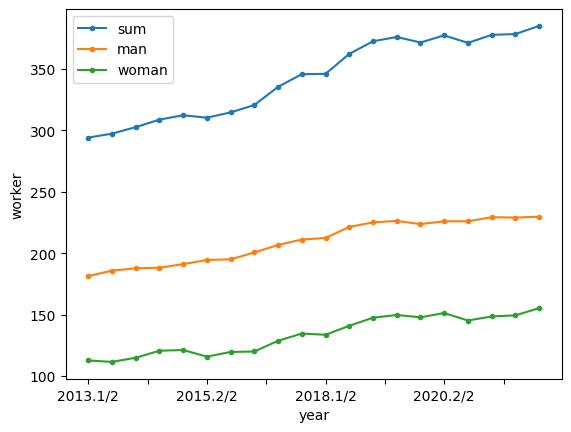

In [ ]:
plt.figure(figsize=(12, 12))
work.plot(marker='.')
plt.xlabel('year')
plt.ylabel('worker')
plt.legend(('sum','man','woman'))
plt.show() #주황 : 남자 / 초록 : 여자

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integ

2023년 예측된 취업자 수 (ARIMA): 389.4
2024년 예측된 취업자 수 (ARIMA): 393.8
2025년 예측된 취업자 수 (ARIMA): 398.3
ARIMA 모델 AIC: 128.97
ARIMA 모델 BIC: 131.81


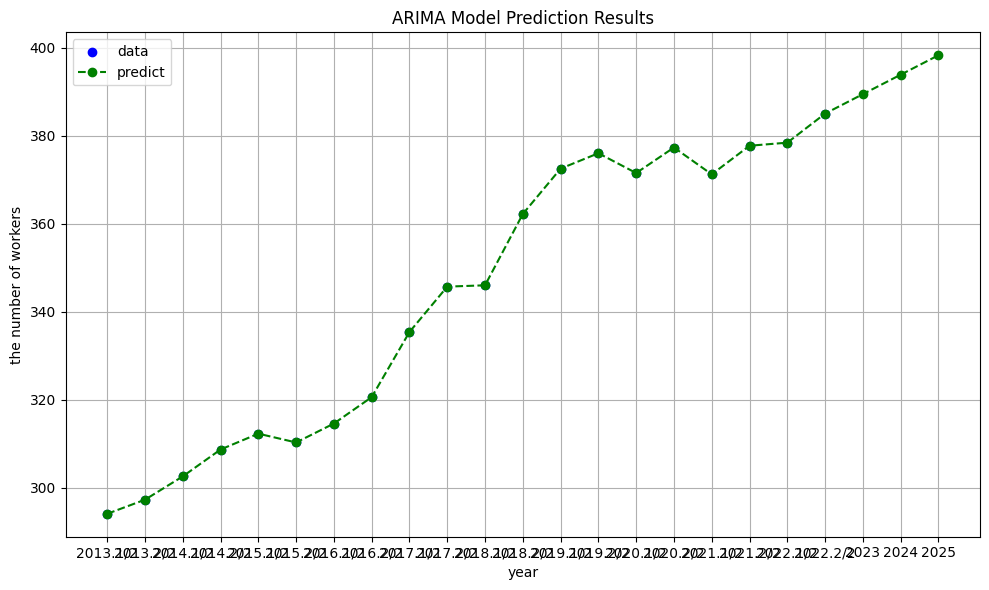

In [ ]:
# ARIMA 모델 생성 및 훈련
model = ARIMA(work['계'], order=(1, 1, 1))  # (p, d, q) 값 설정
model_fit = model.fit()

# 예측할 년도 데이터 생성
future_years = np.array([2023, 2024, 2025])

# ARIMA 모델 예측
forecast = model_fit.forecast(steps=len(future_years))

# 결과 출력
for year, predicted_value_arima in zip(future_years, forecast):
    print(f"{year}년 예측된 취업자 수 (ARIMA): {predicted_value_arima:.1f}")

print(f"ARIMA 모델 AIC: {model_fit.aic:.2f}")
print(f"ARIMA 모델 BIC: {model_fit.bic:.2f}")

# 시각화
plt.figure(figsize=(10, 6))
plt.scatter(work.index, work['계'], color='blue', label='실제 데이터')
plt.plot(work.index.tolist() + future_years.tolist(), work['계'].tolist() + forecast.tolist(), color='green', linestyle='--', marker='o', label='ARIMA 예측')
plt.xlabel('year')
plt.ylabel('the number of workers')
plt.title('ARIMA Model Prediction Results')
plt.legend(('data','predict'))
plt.grid(True)
plt.tight_layout()
plt.show()

##천안시 청년고용률 변화 현황 (15-29세)

In [ ]:
boy = pd.read_csv('청년고용률.csv',encoding='cp949') #천안시 청년고용률 데이터 불러오기
boy = boy.set_index('연도')
boy

,청년고용률
연도,
2013.1/2,39.5
2013.2/2,34.6
2014.1/2,38.1
2014.2/2,37.4
2015.1/2,37.8
2015.2/2,35.6
2016.1/2,35.0
2016.2/2,34.2
2017.1/2,36.6


<Figure size 1200x1200 with 0 Axes>

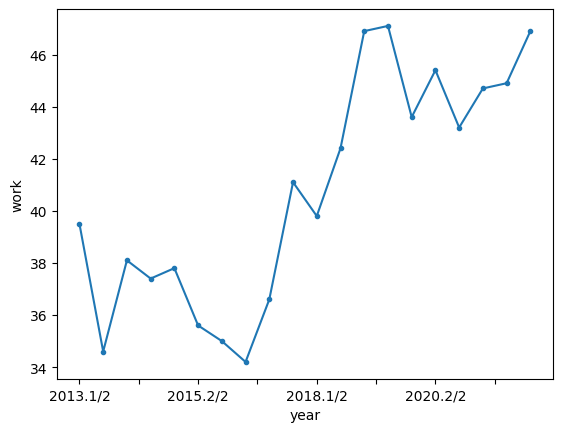

In [ ]:
plt.figure(figsize=(12, 12))
boy.plot(marker='.').get_legend().remove()
plt.xlabel('year')
plt.ylabel('work')

plt.show()

회귀선을 그려보려 했으나 지속된 오류로 실패!

##천안시 각종 기업 현황

In [ ]:
!pip install konlpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 35.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.3/465.3 kB 38.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from konlpy.tag import Komoran
from collections import Counter

In [ ]:
#산업단지 기업 현황 (2022/6 기준)
ind = pd.read_csv('산업단지.csv',encoding='cp949') #천안시 산업단지 기업 데이터 불러오기
ind

,단지명,회사명,공장대표주소(도로명),전화번호
0,천안산업기술일반산업단지,주식회사 두코,"충청남도 천안시 서북구 직산읍 직산로 136, 생산관 2105호 (직산읍)",1644-3880
1,천안마정일반산업단지,(주)케이와이컴퍼니,충청남도 천안시 서북구 직산읍 금곡로 52-20,1599-3176
2,천안산업기술일반산업단지,주식회사 바이콘,"충청남도 천안시 서북구 직산읍 직산로 136, 생산관 2305호",1566-7185
3,천안산업기술일반산업단지,(주)인피닉스,"충청남도 천안시 서북구 직산읍 직산로 136, 충남테크노파크 영상관 506호",1688-0201
4,천안산업기술일반산업단지,(주)에스피에스,"충청남도 천안시 서북구 직산읍 직산로 136, 3102호(충남테크노파크 생산관)",070-8871-5835
...,...,...,...,...
964,천안풍세일반산업단지,(주)에이치케이피앤에스,충청남도 천안시 동남구 풍세면 풍세산단로 50,NaN
965,천안풍세일반산업단지,주식회사 유엔아이,"충청남도 천안시 동남구 풍세면 풍세산단3로 20, 2동, 3동",NaN
966,천안풍세일반산업단지,오트밀식품,충청남도 천안시 동남구 풍세면 용정리 993번지,NaN
967,천안풍세일반산업단지,주식회사 세원이엔지,충청남도 천안시 동남구 풍세면 풍세산단로 226-8,NaN


In [ ]:
ind['단지명'].value_counts() #천안제3일반산업단지에 가장 많은 기업이 위치하고 있다.

천안제3일반산업단지      185
천안산업기술일반산업단지    128
천안제4일반산업단지      125
천안백석농공단지        119
천안풍세일반산업단지      100
천안제2일반산업단지       80
천안마정일반산업단지       63
천안제5일반산업단지       54
천안직산농공단지         41
천안외국인투자지역        35
천안천흥일반산업단지       19
천안5산단외국인투자지역     13
천안동면농공단지          4
천안목천농공단지          3
Name: 단지명, dtype: int64

In [ ]:
# 형태소 분석기를 사용하여 '회사명'에서 명사 형태소를 추출합니다.
komoran = Komoran()
words = ind['회사명'].apply(lambda x: [word for word, pos in komoran.pos(x) if pos == 'NNG' and len(word) > 1])

# 불용어(stopwords) 리스트를 정의합니다.
stopwords = ['주식회사', '(주)', '영상관', '생산관', '생산', '공장대표주소']

# 불용어와 한 글자를 제외하고 가장 많이 나온 단어를 찾습니다.
filtered_words = [word for sublist in words for word in sublist if word not in stopwords]
most_common_words = Counter(filtered_words).most_common()

print(most_common_words)

[('테크', 59), ('시스템', 14), ('에이', 13), ('엔지니어링', 13), ('테크놀로지', 8), ('푸드', 5), ('코스', 4), ('대상', 4), ('컴퍼니', 3), ('하이테크', 3), ('물산', 3), ('성원', 3), ('기업', 3), ('나래', 3), ('식품', 3), ('아이', 3), ('동원', 2), ('오토메이션', 2), ('일광', 2), ('한울', 2), ('소재', 2), ('상상', 2), ('포토', 2), ('엑스', 2), ('동일', 2), ('산업', 2), ('태성', 2), ('쓰리', 2), ('명문', 2), ('열기', 2), ('다원', 2), ('사업장', 2), ('중오', 2), ('사회', 1), ('보호', 1), ('작업장', 1), ('미디어', 1), ('삼현', 1), ('선명', 1), ('컨덕터', 1), ('아트', 1), ('구비', 1), ('아인스', 1), ('연합', 1), ('씨티', 1), ('정형', 1), ('제일', 1), ('부흥', 1), ('메리트', 1), ('영상', 1), ('웅비', 1), ('견지', 1), ('지일', 1), ('금환', 1), ('쎄븐', 1), ('나이', 1), ('삼우', 1), ('상승', 1), ('자평', 1), ('사무기기', 1), ('농기', 1), ('축산물', 1), ('공판장', 1), ('폴리머', 1), ('알티', 1), ('사무소', 1), ('대아', 1), ('환경', 1), ('특장', 1), ('기사', 1), ('청실', 1), ('홍실', 1), ('토스', 1), ('판금', 1), ('방주', 1), ('노무', 1), ('컨설팅', 1), ('콘트롤', 1), ('전원', 1), ('대신', 1), ('스냅', 1), ('오병이어', 1), ('태양광', 1), ('창성', 1), ('엑시', 1), ('이데아', 1), ('무역', 1), ('수경', 

In [ ]:
#제조업체 현황 (2022/9 기준)
make = pd.read_csv('제조업체.csv',encoding='cp949') #천안시 제조업체 기업 데이터 불러오기
make

,업종명,기업체명,소재지,주생산품,전화번호
0,고무제품 및 플라스틱제품,(주)동아수지산업,충청남도 천안시 서북구 직산읍 금곡로 52-5,플리스틱 및 절연제품가공,041-417-7801
1,기타제품,KY컴퍼니,충청남도 천안시 서북구 직산읍 금곡로 52-20,마스크,1599-3176
2,기타기계 및 장비,N&P시스템,충청남도 천안시 서북구 직산읍 금곡로 52-11,자동화기기,070-4352-4760
3,기타제품,RP이엔지,충청남도 천안시 서북구 직산읍 금곡로 57,특수구조물제작,NaN
4,고무제품 및 플라스틱제품,남주테크,충청남도 천안시 서북구 직산읍 금곡로 45,기타부품제작,NaN
...,...,...,...,...,...
3186,비금속광물제,휴먼이엔티주식회사,충청남도 천안시 서북구 성거읍 망향로 903-6,"패널,인방제,바닥제구조물, 디자인형울타리",041-622-0118
3187,식료품,흥림농산,충청남도 천안시 동남구 수신면 장산동길 168-27,"참기름,압착식용유",NaN
3188,인쇄 및 기록매체복제업,희성폴리머(주),충청남도 천안시 서북구 성환읍 천안대로 2131 (성환읍) 외 1필지,"포장재, 광고지, 천막지",041-559-1000
3189,기타기계 및 장비,희영,충청남도 천안시 서북구 직산읍 금곡로 141 ((주)그린테크산업) (총 3 필지) ...,금형제조업,041-583-1677


In [ ]:
make['업종명'].value_counts() #기타가 가장 많고, 그 이후로는 금속가공제품과 고무 및 플라스틱 / 전기 장비 / 식료품 순으로 많다.

기타기계 및 장비                   723
금속가공제품(기계 및 가구제외)           371
고무제품 및 플라스틱제품               280
전기장비                        280
식료품                         274
전자부품, 컴퓨터, 영상, 음향 및 통신장비    223
화학물질 및 화학제품:의약품제외           215
자동차 및 트레일러                  173
의료, 정밀, 광학기기 및 시계           104
비금속광물제                       97
섬유제품                         89
펄프,종이 및 종이제품                 75
기타제품                         49
목재 및 나무제품(가구제외)              44
의료용물질 및 의약품                  43
1차금속                         38
인쇄 및 기록매체복제업                 31
가구                           26
산업용 기계 및 장비수리업               17
기타운송장비                       14
음료                           11
의복,의복액세서리 및 모피제품             11
코크스, 연탄 및 석유정제품               2
Name: 업종명, dtype: int64

In [ ]:
make['주생산품'].value_counts() #자동차부품을 생산하는 제조업체가 가장 많고, 그 이후로는 마스크, 화장품 등이 가장 많다.

자동차부품                            37
마스크                              20
화장품                              19
철구조물                             12
골판지상자                            12
                                 ..
액체연료여과기 등                         1
미끄럼방지제                            1
전동기(DC모터)                         1
PDP X.Y,CERAMIC TRIMMER,습도센서기     1
차량공조 열교환기                         1
Name: 주생산품, Length: 2798, dtype: int64

In [ ]:
# 형태소 분석기를 사용하여 '기업체명'에서 명사 형태소를 추출합니다.
komoran = Komoran()
words = make['기업체명'].apply(lambda x: [word for word, pos in komoran.pos(x) if pos == 'NNG' and len(word) > 1])

# 불용어(stopwords) 리스트를 정의합니다.
stopwords = ['주식회사', '(주)', '영상관', '생산관', '생산', '공장대표주소']

# 불용어와 한 글자를 제외하고 가장 많이 나온 단어를 찾습니다.
filtered_words = [word for sublist in words for word in sublist if word not in stopwords]
most_common_words = Counter(filtered_words).most_common()

print(most_common_words)

[('테크', 199), ('엔지니어링', 43), ('식품', 31), ('에이', 30), ('푸드', 27), ('시스템', 26), ('기업', 20), ('산업', 20), ('테크놀로지', 14), ('종합', 12), ('하이테크', 9), ('코스', 9), ('농사', 9), ('특장', 9), ('아이', 8), ('태성', 8), ('동일', 7), ('프라스틱', 7), ('소재', 7), ('복지회', 6), ('다원', 6), ('물산', 6), ('컴퍼니', 5), ('사업단', 5), ('사업장', 5), ('중기', 5), ('철강', 5), ('제일', 5), ('선영', 4), ('선진', 4), ('쓰리', 4), ('무역', 4), ('비젼', 4), ('엑스', 4), ('해성', 4), ('나래', 4), ('대상', 4), ('사회', 4), ('한마음', 3), ('대아', 3), ('아트', 3), ('아우', 3), ('삼일', 3), ('농기계', 3), ('씨티', 3), ('신소재', 3), ('통상', 3), ('포토', 3), ('한길', 3), ('금형', 3), ('세라믹', 3), ('성원', 3), ('영농', 3), ('신진', 3), ('우인', 3), ('콘트롤', 2), ('라이팅', 2), ('글라스', 2), ('마루', 2), ('명문', 2), ('상신', 2), ('송림', 2), ('쎄븐', 2), ('공장', 2), ('아인스', 2), ('운영', 2), ('노스', 2), ('일광', 2), ('창성', 2), ('대리석', 2), ('오토메이션', 2), ('한울', 2), ('진메', 2), ('국제', 2), ('나라', 2), ('미곡', 2), ('처리장', 2), ('대신', 2), ('자재', 2), ('동원', 2), ('냉동', 2), ('방주', 2), ('재단', 2), ('농기', 2), ('상상', 2), ('판지', 2), ('시대', 2), ('수

In [ ]:
#공중위생업소 현황 (2022/9 기준)
san = pd.read_csv('공중위생업소.csv',encoding='cp949') #천안시 공중위생업소 데이터 불러오기
san

,위생업소구분,업소명,소재지도로명주소,소재지지번주소,전화번호
0,숙박업(일반),동궁여관,"충청남도 천안시 서북구 성환읍 성환2로 134, 동궁장 2,3층",충청남도 천안시 서북구 성환읍 성환리 280-8 동궁장,041-581-9191
1,숙박업(일반),한양파크장여관,충청남도 천안시 서북구 봉정로 103 (성정동),충청남도 천안시 서북구 성정동 743-5,041-574-2002
2,숙박업(일반),이화모텔,충청남도 천안시 서북구 차돌로 10 (쌍용동),충청남도 천안시 서북구 쌍용동 533-5,041-572-7033
3,숙박업(일반),성거여인숙,충청남도 천안시 서북구 성거읍 성거길 129,충청남도 천안시 서북구 성거읍 저리 52-3,041-622-0785
4,숙박업(일반),금관여관,충청남도 천안시 서북구 입장면 입장로 144,충청남도 천안시 서북구 입장면 하장리 63,041-583-5135
...,...,...,...,...,...
2668,"피부미용업, 네일미용업, 화장ㆍ분장 미용업",반하다,"충청남도 천안시 동남구 풍세로 798, 1층 105호 (청당동)",충청남도 천안시 동남구 청당동 396-12,NaN
2669,"피부미용업, 네일미용업, 화장ㆍ분장 미용업",하늘연네일,"충청남도 천안시 동남구 터미널6길 9, 1층 (신부동)",충청남도 천안시 동남구 신부동 804 1층,NaN
2670,"피부미용업, 네일미용업, 화장ㆍ분장 미용업",제이와이뷰티,"충청남도 천안시 동남구 통정8로 17, 1층 (신방동)",충청남도 천안시 동남구 신방동 1385,NaN
2671,"피부미용업, 네일미용업, 화장ㆍ분장 미용업",더더네일,"충청남도 천안시 동남구 중앙로 213, 1층 (신부동)",충청남도 천안시 동남구 신부동 371-25 1층,NaN


In [ ]:
san['위생업소구분'].value_counts() #일반미용업이 가장 많고, 그 이후로 피부, 숙박, 네일, 미용이 많다.

일반미용업                      1197
피부미용업                       321
숙박업(일반)                     316
네일미용업                       228
미용업                         122
종합미용업                       112
일반미용업, 화장ㆍ분장 미용업             82
피부미용업, 네일미용업                 60
화장ㆍ분장 미용업                    55
네일미용업, 화장ㆍ분장 미용업             41
피부미용업, 네일미용업, 화장ㆍ분장 미용업      38
피부미용업, 화장ㆍ분장 미용업             32
일반미용업, 네일미용업                 23
일반미용업, 네일미용업, 화장ㆍ분장 미용업      16
일반미용업, 피부미용업                 15
숙박업(생활)                       9
일반미용업, 피부미용업, 화장ㆍ분장 미용업       4
일반미용업, 피부미용업, 네일미용업           2
Name: 위생업소구분, dtype: int64

In [ ]:
# 형태소 분석기를 사용하여 '업소명'에서 명사 형태소를 추출합니다.
komoran = Komoran()
words = san['업소명'].apply(lambda x: [word for word, pos in komoran.pos(x) if pos == 'NNG' and len(word) > 1])

# 한 글자를 제외하고 가장 많이 나온 단어를 찾습니다.
filtered_words = [word for sublist in words for word in sublist if word not in stopwords and len(word) > 1]
most_common_words = Counter(filtered_words).most_common()

print(most_common_words)

[('헤어', 744), ('스킨케어', 28), ('머리', 21), ('아트', 17), ('오늘', 13), ('메이크업', 13), ('테크', 12), ('사랑', 10), ('아이', 8), ('남성', 8), ('커트', 8), ('미용', 7), ('호텔', 6), ('하루', 6), ('언니', 6), ('관리실', 6), ('정점', 5), ('그날', 5), ('남자', 4), ('미장원', 4), ('공감', 4), ('신불', 4), ('에이', 4), ('메이드', 4), ('마이', 3), ('프로', 3), ('무드', 3), ('포유', 3), ('바이', 3), ('관광호텔', 2), ('비지니스', 2), ('명품', 2), ('창조', 2), ('코디', 2), ('버르장머리', 2), ('메종드', 2), ('단장', 2), ('쓰리', 2), ('모던', 2), ('천연', 2), ('나래', 2), ('핸섬', 2), ('전문', 2), ('제니', 2), ('차밍', 2), ('미용실', 2), ('은빛', 2), ('스킨', 2), ('체형', 2), ('주의', 2), ('황실', 2), ('예인', 2), ('골든', 2), ('행복', 2), ('하자', 2), ('낭만', 2), ('꾸밈', 2), ('성장', 2), ('키즈', 2), ('국빈', 2), ('로얄', 1), ('삼일', 1), ('강변', 1), ('씨티', 1), ('스프', 1), ('프리마', 1), ('구구', 1), ('블럭', 1), ('쎄븐', 1), ('꽁지', 1), ('꽃샘', 1), ('프라자', 1), ('모레', 1), ('새내기', 1), ('수연', 1), ('플러스', 1), ('클럽', 1), ('사람', 1), ('나라', 1), ('진실', 1), ('매니아', 1), ('이야기', 1), ('클리닉', 1), ('지연', 1), ('프리티', 1), ('골목', 1), ('신주', 1), ('은수', 1)

#천안시 전통시장 현황

In [ ]:
# 병천시장 (2022/9 기준)
mar1 = pd.read_csv('천안 병천시장.csv',encoding='cp949')
mar1

,상호,운영시간,업종,도로명주소,지번주소,전화번호,위도,경도
0,태양상회,08:00~18:00,마트/식품,충청남도 천안시 동남구 병천면 아우내장터1길 30,충청남도 천안시 동남구 병천면 병천리 294-4,041-564-8793,36.761016,127.297228
1,병천이용원,07:00~18:00,생활서비스,충청남도 천안시 동남구 병천면 아우내장터1길 30,충청남도 천안시 동남구 병천면 병천리 294-4,041-564-0522,36.761081,127.297273
2,오토바이미장원,08:00~18:00,생활서비스,충청남도 천안시 동남구 병천면 아우내장터1길 30,충청남도 천안시 동남구 병천면 병천리 294-4,041-564-8282,36.761134,127.297307
3,현제종합사료,08:00~18:00,기타,충청남도 천안시 동남구 병천면 아우내장터1길 30,충청남도 천안시 동남구 병천면 병천리 294-4,041-564-8282,36.761175,127.297333
4,공실 1,공실,기타,충청남도 천안시 동남구 병천면 아우내장터1길 32,충청남도 천안시 동남구 병천면 병천리 293-5,NaN,36.761311,127.297421
5,공실 2,폐업,기타,충청남도 천안시 동남구 병천면 아우내장터1길 32,충청남도 천안시 동남구 병천면 병천리 293-5,NaN,36.761348,127.297447
6,공실 3,폐업,기타,충청남도 천안시 동남구 병천면 아우내장터1길 38,충청남도 천안시 동남구 병천면 병천리 164-2,NaN,36.761855,127.297745
7,공실 4,폐업,기타,충청남도 천안시 동남구 병천면 아우내장터1길 38,충청남도 천안시 동남구 병천면 병천리 164-2,NaN,36.761895,127.297774
8,병천슈퍼,07:00~19:30,마트/식품,충청남도 천안시 동남구 병천면 아우내장터1길 36,충청남도 천안시 동남구 병천면 병천리 293-9,041-564-1207,36.761540,127.297578
9,태평전기,08:00~18:00,전기/가전,충청남도 천안시 동남구 병천면 아우내장터1길 38,충청남도 천안시 동남구 병천면 병천리 164-2,041-564-3339,36.761791,127.297725


In [ ]:
mar1['업종'].value_counts()

기타       18
생활서비스     5
의류/잡화     5
마트/식품     3
전기/가전     2
생활용품      2
침구/주단     1
식당/음식     1
Name: 업종, dtype: int64

In [ ]:
mar1['운영시간'].value_counts() #공실이 많고, 대부분의 가게는 8시부터 6시까지 운영함을 알 수 있다.

공실             7
08:00~18:00    6
폐업             6
미영업            3
10:00~17:00    2
07:00~19:00    2
09:00~18:00    2
07:00~18:00    1
07:00~19:30    1
10:00~18:30    1
08:00~17:00    1
09:00~17:00    1
08:30~14:00    1
09:00~15:00    1
07:30~18:30    1
08:20~13:30    1
Name: 운영시간, dtype: int64

In [ ]:
# 형태소 분석기를 사용하여 '상호'에서 명사 형태소를 추출합니다.
komoran = Komoran()
words = mar1['상호'].apply(lambda x: [word for word, pos in komoran.pos(x) if pos == 'NNG' and len(word) > 1])

# 한 글자를 제외하고 가장 많이 나온 단어를 찾습니다.
filtered_words = [word for sublist in words for word in sublist if word not in stopwords and len(word) > 1]
most_common_words = Counter(filtered_words).most_common()

print(most_common_words)

[('공실', 13), ('중앙', 2), ('상회', 2), ('오토바이', 1), ('미장원', 1), ('종합', 1), ('철물', 1), ('포목상', 1), ('용품', 1), ('평화', 1), ('동화상', 1), ('닭집', 1), ('아우', 1), ('팬시', 1)]


In [ ]:
# 성정시장 (2022/9 기준)

mar2 = pd.read_csv('천안 성정시장.csv',encoding='cp949')
mar2

,상호,운영시간,업종,도로명주소,지번주소,전화번호,위도,경도
0,한인테리어,미영업,기타,충청남도 천안시 서북구 양지21길 5,충청남도 천안시 서북구 성정동 726-12,NaN,36.813482,127.137164
1,스마일LED,"월 ~ 금 09:00~18:00, 토 09:00~12:00",전기/가전,충청남도 천안시 서북구 양지21길 5,충청남도 천안시 서북구 성정동 726-12,041-579-2440,36.813437,127.137162
2,달팽이커피앤필름,10:00~20:00,식당/음식,충청남도 천안시 서북구 양지21길 5,충청남도 천안시 서북구 성정동 726-12,041-556-3533,36.813360,127.137184
3,쌍용스토아,00:00~24:00,마트/식품,충청남도 천안시 서북구 성정로 64,충청남도 천안시 서북구 성정동 726-1,041-576-7008,36.813689,127.137226
4,화로담,15:00~24:00,식당/음식,충청남도 천안시 서북구 성정로 66,충청남도 천안시 서북구 성정동 726-17,041-579-1093,36.813673,127.137395
...,...,...,...,...,...,...,...,...
115,5단지구두종합병원,09:00~18:00,생활서비스,충청남도 천안시 서북구 성정로 86,충청남도 천안시 서북구 성정동 727-4,NaN,36.813574,127.139773
116,기가찬참숯민물장어,11:30~23:00,식당/음식,충청남도 천안시 서북구 양지22길 49,충청남도 천안시 서북구 성정동 727-6,041-575-6009,36.813288,127.139646
117,공실10,공실,기타,충청남도 천안시 서북구 양지22길 49,충청남도 천안시 서북구 성정동 727-6,NaN,36.813369,127.139644
118,덕꾼 천안점,17:00~24:00,식당/음식,충청남도 천안시 서북구 양지7길 10,충청남도 천안시 서북구 성정동 727-4,041-579-5279,36.811518,127.138789


In [ ]:
mar2['업종'].value_counts() #식당이 가장 많다.

식당/음식     39
기타        22
생활서비스     17
의류/잡화     11
의료/건강      8
마트/식품      6
축산물        5
전기/가전      4
침구/주단      3
농산물/청과     3
수산물        1
생활용품       1
Name: 업종, dtype: int64

In [ ]:
mar2['운영시간'].value_counts() #대부분 9시에 열고 8시나 9시에 닫는 가게가 많음을 알 수 있다.

10:00~20:00                                      8
공실                                               7
09:00~20:00                                      6
09:00~21:00                                      6
08:00~20:00                                      6
09:00~19:00                                      6
10:00~22:00                                      5
미영업                                              4
00:00~24:00                                      4
폐업                                               3
10:00~19:00                                      3
화~일 10:00~20:00                                  3
09:00~18:00                                      3
08:00~21:00                                      3
07:00~23:00                                      2
08:00~18:30                                      2
09:00~20:30                                      2
10:00~18:00                                      2
12:00~24:00                                      2
09:30~19:30                    

In [ ]:
# 형태소 분석기를 사용하여 '상호'에서 명사 형태소를 추출합니다.
komoran = Komoran()
words = mar2['상호'].apply(lambda x: [word for word, pos in komoran.pos(x) if pos == 'NNG' and len(word) > 1])

# 한 글자를 제외하고 가장 많이 나온 단어를 찾습니다.
filtered_words = [word for sublist in words for word in sublist if word not in stopwords and len(word) > 1]
most_common_words = Counter(filtered_words).most_common()

print(most_common_words)

[('공실', 10), ('성정', 4), ('세상', 3), ('헤어', 3), ('상회', 2), ('시장', 2), ('세탁소', 2), ('인테리어', 1), ('화로', 1), ('신화', 1), ('철물', 1), ('커텐', 1), ('노래', 1), ('연습장', 1), ('국민', 1), ('저잣거리', 1), ('수제', 1), ('고향', 1), ('행복', 1), ('언니', 1), ('전국', 1), ('아구찜', 1), ('시골', 1), ('전집', 1), ('벽사', 1), ('맛집', 1), ('의류', 1), ('이야기', 1), ('식품', 1), ('알곡', 1), ('할매', 1), ('보리밥', 1), ('건강원', 1), ('영아', 1), ('즉석', 1), ('참살', 1), ('종합', 1), ('숯불', 1), ('고기', 1), ('사랑', 1), ('정형외과', 1), ('후생', 1), ('치과', 1), ('크리닉', 1), ('오브', 1), ('축산물', 1), ('직매장', 1), ('참숯', 1), ('동네', 1)]


In [ ]:
# 성환이화시장 (2022/8 기준)

mar3 = pd.read_csv('천안 성환이화시장.csv',encoding='cp949')
mar3

,상호,운영시간,업종,도로명주소,지번주소,전화번호,위도,경도
0,찐흑염소,09:00~18:00,의료/건강,충청남도 천안시 서북구 성환읍 성환12길 11,충청남도 천안시 서북구 성환읍 성환리 449,041-583-3800,36.917582,127.129265
1,신원육가공 직영점,11:00~23:00,축산물,충청남도 천안시 서북구 성환읍 성환12길 13,충청남도 천안시 서북구 성환읍 성환리 449-510,041-582-1616,36.917584,127.129416
2,정육식당,11:00-23:00,식당/음식,충청남도 천안시 서북구 성환읍 성환12길 13,충청남도 천안시 서북구 성환읍 성환리 449-510,041-582-1616,36.917604,127.129518
3,이화막곱창,09:30~22:00,식당/음식,충청남도 천안시 서북구 성환읍 성환12길 13-2,충청남도 천안시 서북구 성환읍 성환리 449-506,041-588-5009,36.917578,127.129583
4,순영미용실,임시 영업 중단,생활서비스,충청남도 천안시 서북구 성환읍 성환12길 13-4,충청남도 천안시 서북구 성환읍 성환리 449-6,041-584-7494,36.917815,127.129505
5,해동집,07:00~19:00,식당/음식,충청남도 천안시 서북구 성환읍 성환12길 13-6,충청남도 천안시 서북구 성환읍 성환리 449-6,041-585-9600,36.917961,127.129474
6,제일닭집,06:00~21:00,축산물,충청남도 천안시 서북구 성환읍 성환12길 13-12,충청남도 천안시 서북구 성환읍 성환리 449-6,041-582-4203,36.918104,127.129520
7,제일한복,09:00~19:00,의류/잡화,충청남도 천안시 서북구 성환읍 성환시장길 4,충청남도 천안시 서북구 성환읍 성환리 449-6,041-581-5290,36.917958,127.129748
8,조양상회,09:00~19:00,의류/잡화,충청남도 천안시 서북구 성환읍 성환시장길 3,충청남도 천안시 서북구 성환읍 성환리 449-135,041-581-2402,36.917908,127.129748
9,장미의류,09:00~19:00,의류/잡화,충청남도 천안시 서북구 성환읍 성환시장길 1,충청남도 천안시 서북구 성환읍 성환리 449-6,041-581-2078,36.917806,127.129751


In [ ]:
mar3['업종'].value_counts() #식당이 가장 많다.

식당/음식     21
생활서비스      7
축산물        5
마트/식품      5
기타         5
의류/잡화      4
농산물/청과     4
의료/건강      2
전기/가전      1
Name: 업종, dtype: int64

In [ ]:
mar3['운영시간'].value_counts() #8시에 열고 6시에 닫거나, 9시에 열고 7시에 닫는 가게가 가장 많다.

08:00~18:00                                     4
09:00~19:00                                     4
08:00~20:00                                     3
00:00~24:00                                     3
07:00~20:00                                     3
08:00~17:00                                     3
06:00~19:00                                     2
11:00~19:00                                     2
09:00~18:00                                     2
06:00~21:00                                     2
07:00~19:00                                     2
06:00~22:00                                     2
공실                                              1
10:00-21:00                                     1
06:00~23:00                                     1
05:00~18:00                                     1
(*장날만 영업)10:00~18:00                            1
07:00~18:00                                     1
10:00~22:00                                     1
(장날 전~ 장날 당일)07:00~19:00                        1


In [ ]:
# 형태소 분석기를 사용하여 '상호'에서 명사 형태소를 추출합니다.
komoran = Komoran()
words = mar3['상호'].apply(lambda x: [word for word, pos in komoran.pos(x) if pos == 'NNG' and len(word) > 1])

# 한 글자를 제외하고 가장 많이 나온 단어를 찾습니다.
filtered_words = [word for sublist in words for word in sublist if word not in stopwords and len(word) > 1]
most_common_words = Counter(filtered_words).most_common()

print(most_common_words)


[('닭집', 3), ('상회', 3), ('장터', 3), ('제일', 2), ('시장', 2), ('직영점', 1), ('정육', 1), ('의류', 1), ('형제', 1), ('종합', 1), ('설비', 1), ('보장', 1), ('건강원', 1), ('기름집', 1), ('유일', 1), ('옛날', 1), ('장옥', 1), ('동화상', 1), ('보리밥', 1), ('떡집', 1), ('원조', 1), ('공실', 1), ('할매', 1), ('즉석', 1), ('하늘', 1)]


In [ ]:
# 역전시장 (2022/9 기준)
mar4 = pd.read_csv('천안 역전시장.csv',encoding='cp949')
mar4

,상호,운영시간,업종,도로명주소,지번주소,전화번호,위도,경도
0,은성다방,09:00~21:00,식당/음식,충청남도 천안시 동남구 공설시장1길 2,충청남도 천안시 동남구 대흥동 63-3,041-552-6630,36.809205,127.148900
1,서경석안경원,09:00~20:00,생활서비스,충청남도 천안시 동남구 공설시장1길 2,충청남도 천안시 동남구 대흥동 63-3,041-562-4625,36.809205,127.148900
2,공실 1,공실,기타,충청남도 천안시 동남구 공설시장1길 2,충청남도 천안시 동남구 대흥동 63-3,NaN,36.809211,127.148840
3,공실 2,공실,기타,충청남도 천안시 동남구 공설시장1길 2,충청남도 천안시 동남구 대흥동 63-3,NaN,36.809203,127.148927
4,결혼상담소,미영업,기타,충청남도 천안시 동남구 공설시장1길 2,충청남도 천안시 동남구 대흥동 63-3,041-553-7865,36.809203,127.148926
...,...,...,...,...,...,...,...,...
222,공실 61,공실,기타,충청남도 천안시 동남구 문화로 6,충청남도 천안시 동남구 대흥동 18,NaN,36.810866,127.149154
223,공실 63,폐업,기타,충청남도 천안시 동남구 공설시장1길 18,충청남도 천안시 동남구 대흥동 17-2,NaN,36.810613,127.149379
224,공실 62,공실,기타,충청남도 천안시 동남구 공설시장3길 4,충청남도 천안시 동남구 대흥동 39-1,NaN,36.810072,127.148711
225,찜질체험장,10:00~18:00,기타,충청남도 천안시 동남구 문화로 6,충청남도 천안시 동남구 대흥동 18,041-622-3369,36.810836,127.149225


In [ ]:
mar4['업종'].value_counts() #기타가 가장 많고 그 뒤로는 식당이 가장 많다.

기타        109
식당/음식      51
생활서비스      23
의류/잡화      13
의료/건강      10
마트/식품       6
농산물/청과      4
전기/가전       3
생활용품        2
축산물         2
수산물         2
침구/주단       2
Name: 업종, dtype: int64

In [ ]:
mar4['운영시간'].value_counts() #공실과 미영업, 폐업이 가장 많은 것으로 보아 역전 시장은 활성화가 제대로 안 되어 있음을 알 수 있다.

공실             47
미영업            36
폐업             16
09:00~18:00    10
09:00~20:00     8
               ..
10:00~17:00     1
10:00~23:00     1
14:00~23:00     1
08:30~19:30     1
09:00~17:30     1
Name: 운영시간, Length: 70, dtype: int64

In [ ]:
# 형태소 분석기를 사용하여 '상호'에서 명사 형태소를 추출합니다.
komoran = Komoran()
words = mar4['상호'].apply(lambda x: [word for word, pos in komoran.pos(x) if pos == 'NNG' and len(word) > 1])

# 한 글자를 제외하고 가장 많이 나온 단어를 찾습니다.
filtered_words = [word for sublist in words for word in sublist if word not in stopwords and len(word) > 1]
most_common_words = Counter(filtered_words).most_common()

print(most_common_words)


[('공실', 63), ('상회', 4), ('중앙', 3), ('체험', 2), ('역전', 2), ('은성', 1), ('결혼상담소', 1), ('활어', 1), ('세탁소', 1), ('세계', 1), ('문화', 1), ('교육', 1), ('식품', 1), ('추억', 1), ('쉼터', 1), ('진흥원', 1), ('시장', 1), ('닭집', 1), ('명보', 1), ('전문', 1), ('농원', 1), ('반점', 1), ('남도', 1), ('밥상', 1), ('장모', 1), ('기물', 1), ('의류', 1), ('매장', 1), ('샘물', 1), ('야식', 1), ('꼬치', 1), ('할인', 1), ('축복', 1), ('도원', 1), ('꽈배기', 1), ('선물', 1), ('코너', 1), ('공설', 1), ('사무실', 1), ('전원', 1), ('동백', 1), ('입쌀', 1), ('버들', 1), ('지회', 1), ('양복점', 1), ('미용', 1), ('헤어', 1), ('냉동', 1), ('작명', 1), ('성인', 1), ('전용', 1), ('컴퓨터', 1), ('세기', 1), ('보석', 1), ('푸드', 1), ('마사지', 1), ('솥밥', 1), ('국제', 1), ('서가', 1), ('철학관', 1), ('평생', 1), ('교육원', 1), ('미소', 1), ('약국', 1), ('지부', 1), ('트레', 1)]


In [ ]:
# 중앙시장 (2022/9 기준)

In [ ]:
mar5 = pd.read_csv('천안 중앙시장.csv', encoding='utf-8')
mar5

,상호,운영시간,업종,도로명주소,지번주소,전화번호,위도,경도
0,청년상회,월~토10:00~18:30,농산물/청과,충청남도 천안시 동남구 대흥로 119,충청남도 천안시 동남구 사직동 284-1,NaN,36.800139,127.149465
1,아시아마트,09:00~21:00,마트/식품,충청남도 천안시 동남구 대흥로 119,충청남도 천안시 동남구 사직동 284-1,041-564-6688,36.800176,127.149401
2,남산계란,08:30~19:30,축산물,충청남도 천안시 동남구 대흥로 119,충청남도 천안시 동남구 사직동 284-1,041-555-0379,36.800197,127.149333
3,공원다방,09:00~18:30,기타,충청남도 천안시 동남구 대흥로 119,충청남도 천안시 동남구 사직동 284-1,041-567-9797,36.800139,127.149465
4,광제당한의원,평일 09:00~19:00토요일 09:00~13:00일요일/공휴일 휴진,의료/건강,충청남도 천안시 동남구 대흥로 119,충청남도 천안시 동남구 사직동 284-1,041-563-1093,36.800139,127.149465
...,...,...,...,...,...,...,...,...
457,국민불교사,09:00~18:00,기타,충청남도 천안시 동남구 큰시장길 32,충청남도 천안시 동남구 사직동 176-5,041-555-2816,36.801892,127.150184
458,은성한약건재약업사,09:00~18:00,의료/건강,충청남도 천안시 동남구 큰시장길 34,충청남도 천안시 동남구 사직동 176-1,041-565-6577,36.801914,127.150406
459,종로보석,09:00~18:00,기타,충청남도 천안시 동남구 큰시장길 34,충청남도 천안시 동남구 사직동 176-1,041-552-2539,36.801912,127.150313
460,별이네과일,08:30~19:00,농산물/청과,충청남도 천안시 동남구 큰시장길 34,충청남도 천안시 동남구 사직동 176-1,NaN,36.801882,127.150400


In [ ]:
mar5['업종'].value_counts() #식당이 가장 많다

식당/음식     103
기타         90
의류/잡화      78
마트/식품      31
농산물/청과     28
의료/건강      28
침구/주단      23
생활서비스      22
수산물        20
생활용품       19
축산물        16
전기/가전       4
Name: 업종, dtype: int64

In [ ]:
mar5['운영시간'].value_counts() #공실이 가장 많고, 9시에 열고 6시에 닫는 게 보통이다.

공실             61
09:00~18:00    39
10:00~18:00    20
09:00~19:00    19
07:00~19:00    17
               ..
09:30-18:00     1
06:00-19:00     1
10:00-18:30     1
08:00-19:00     1
10:00~14:00     1
Name: 운영시간, Length: 125, dtype: int64

In [ ]:
# 형태소 분석기를 사용하여 '상호'에서 명사 형태소를 추출합니다.
komoran = Komoran()
words = mar5['상호'].apply(lambda x: [word for word, pos in komoran.pos(x) if pos == 'NNG' and len(word) > 1])

# 한 글자를 제외하고 가장 많이 나온 단어를 찾습니다.
filtered_words = [word for sublist in words for word in sublist if word not in stopwords and len(word) > 1]
most_common_words = Counter(filtered_words).most_common()

print(most_common_words)


[('공실', 69), ('상회', 37), ('식품', 11), ('수산', 9), ('떡집', 6), ('즉석', 5), ('약업', 4), ('의류', 4), ('야채', 4), ('종합', 4), ('장터', 3), ('중앙', 3), ('시골', 3), ('수산물', 3), ('체형', 3), ('코너', 3), ('부흥', 3), ('계란', 2), ('판매점', 2), ('옛날', 2), ('명품', 2), ('으뜸', 2), ('커텐', 2), ('공판장', 2), ('반점', 2), ('건강원', 2), ('못난이', 2), ('원조', 2), ('순복음', 2), ('직영', 2), ('시장', 2), ('닭집', 2), ('세상', 2), ('신진', 2), ('침구사', 2), ('건재', 2), ('청년', 1), ('일등', 1), ('분식', 1), ('수제', 1), ('무침', 1), ('전문', 1), ('배방', 1), ('축산물', 1), ('산천', 1), ('영화', 1), ('가보', 1), ('자식', 1), ('방앗간', 1), ('보리밥', 1), ('머슴', 1), ('불로', 1), ('할매', 1), ('나들이', 1), ('남가', 1), ('쎈스', 1), ('대추', 1), ('관음', 1), ('생활', 1), ('용품', 1), ('김치', 1), ('소비자', 1), ('교육', 1), ('중앙회', 1), ('지회', 1), ('모녀', 1), ('의료기', 1), ('만복', 1), ('마담', 1), ('여정', 1), ('대별', 1), ('안감', 1), ('헤어', 1), ('로얄', 1), ('삼우', 1), ('도소매', 1), ('수입', 1), ('육류', 1), ('풍농', 1), ('그린', 1), ('탈모', 1), ('행운', 1), ('금장', 1), ('평생', 1), ('식육', 1), ('보장', 1), ('대풍', 1), ('만물상', 1), ('태양', 1), (